Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Tentando carregar arquivo do Google Drive: /content/Previsao_Cancelamento_out_dez_2022.xlsx

Base carregada — Shape: (42, 4)
   Referencia         DataPrevisao  total_contas  valor_cancelamento
0  2021-10-01  2022-09-26 07:37:00          2459            64973.83
1  2021-10-04  2022-09-26 07:40:00             1                0.25
2  2021-10-05  2022-09-26 07:41:00          2202            95620.64
3  2021-10-06  2022-09-26 07:42:00            95             2880.29
4  2021-10-07  2022-09-26 07:43:00           480            12345.21

Tipos:
Referencia             object
DataPrevisao           object
total_contas            int64
valor_cancelamento    float64
dtype: object

Missing:
Referencia            0
DataPrevisao          0
total_contas          0
valor_cancelamento    0
dtype: int64

Coluna de data detectada: 'DataPrevisao'
Shape pós filtro (jan/2020+):

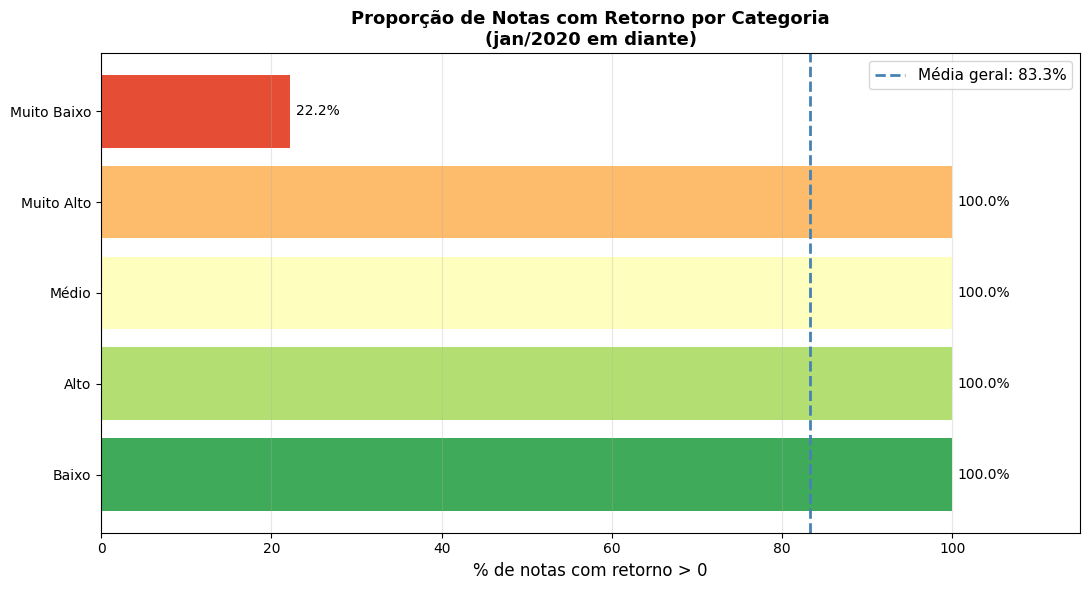


TABELA WOE POR CATEGORIA
categoria_criada  total  eventos  nao_eventos  pct_retorno  dist_eventos  dist_nao_ev     WOE  IV_parcial
      Muito Alto      9        9            0     100.0000        0.2571       0.0000  1.3350      0.3433
           Médio      8        8            0     100.0000        0.2286       0.0000  1.2238      0.2797
           Baixo      8        8            0     100.0000        0.2286       0.0000  1.2238      0.2797
            Alto      8        8            0     100.0000        0.2286       0.0000  1.2238      0.2797
     Muito Baixo      9        2            7      22.2222        0.0571       1.0000 -2.7081      2.5533


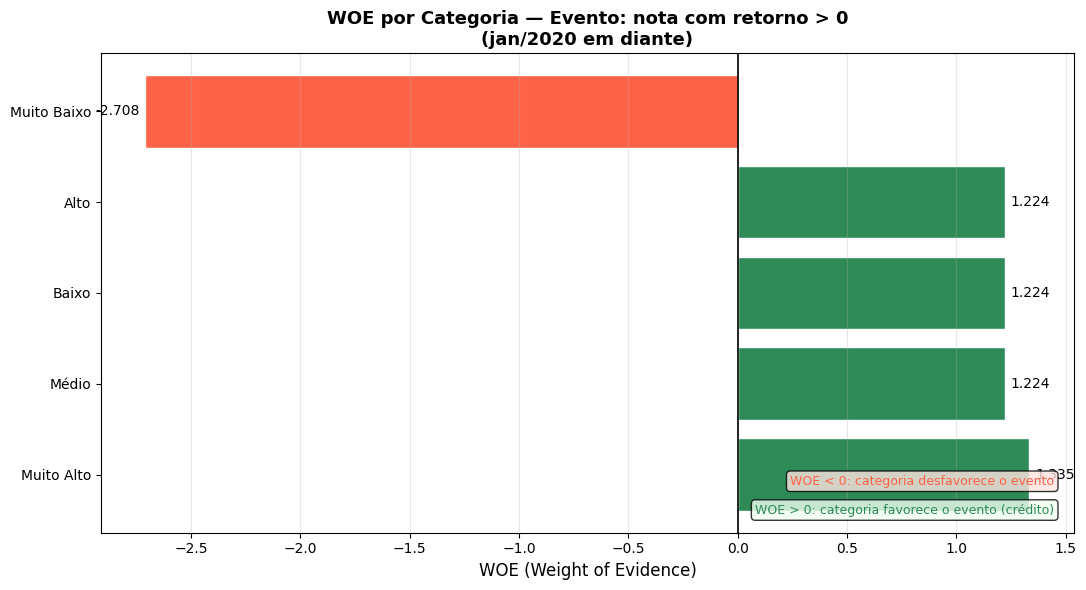

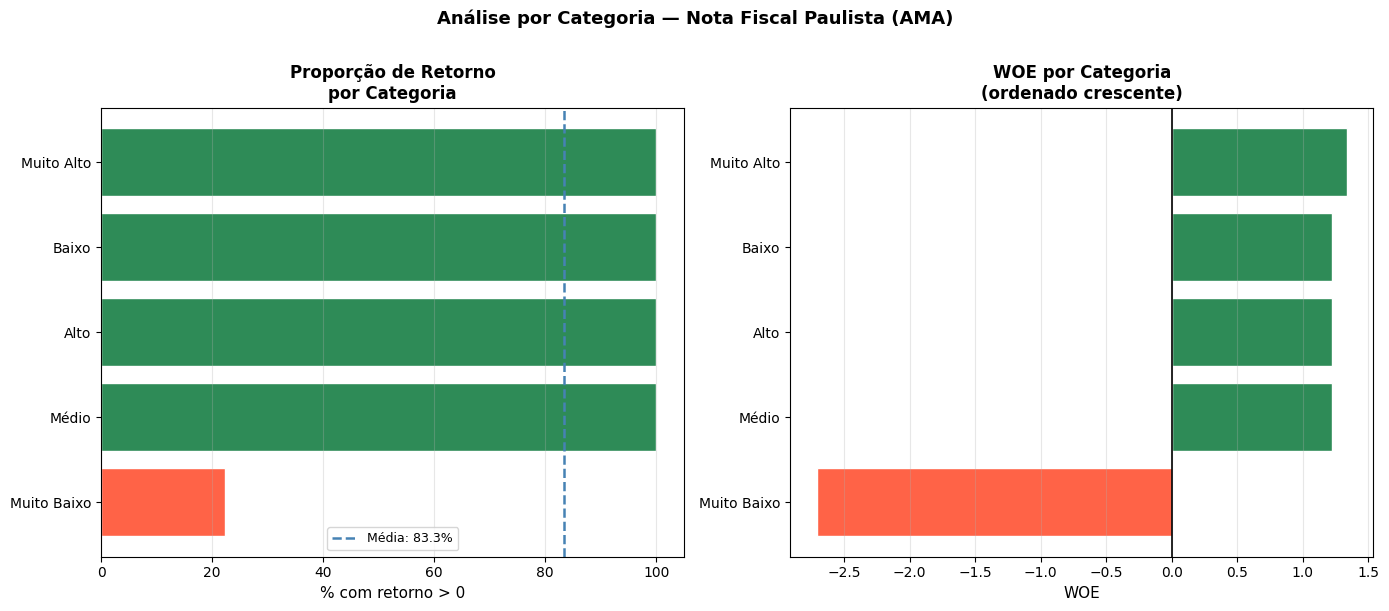


INFORMATION VALUE (IV)

  IV Total = 3.7358
  Interpretação: Poder preditivo MUITO FORTE (verificar)

  IV por categoria (contribuição parcial):
  Muito Alto                  0.3433  ████████████████████████████████████████████████████████████████████
  Médio                       0.2797  ███████████████████████████████████████████████████████
  Baixo                       0.2797  ███████████████████████████████████████████████████████
  Alto                        0.2797  ███████████████████████████████████████████████████████
  Muito Baixo                 2.5533  ███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

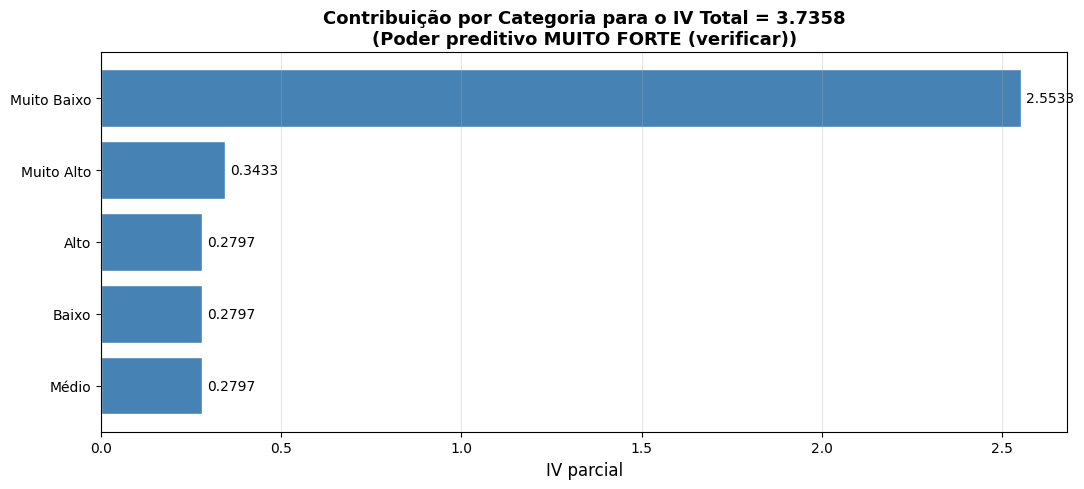


  Referência para interpretação do IV:
  ┌─────────────┬───────────────────────────────────┐
  │     IV      │         Poder Preditivo           │
  ├─────────────┼───────────────────────────────────┤
  │   < 0.02    │  Sem poder preditivo              │
  │ 0.02 – 0.10 │  Fraco                            │
  │ 0.10 – 0.30 │  Médio                            │
  │ 0.30 – 0.50 │  Forte                            │
  │   > 0.50    │  Muito forte (suspeito)            │
  └─────────────┴───────────────────────────────────┘



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import zipfile, glob
import warnings
warnings.filterwarnings('ignore')


# 1. CARREGAR OS DADOS
#    Aceita: .ftr (feather), .pkl (pickle), .zip com um desses ou .xlsx (Excel)

from google.colab import drive
# Para carregar arquivos de forma mais rápida e não interativa (RECOMENDADO):
# 1. Descomente a linha abaixo para montar seu Google Drive.
drive.mount('/content/drive')

# 2. Descomente a linha abaixo e insira o caminho COMPLETO para o seu arquivo no Drive.
#    Exemplo: nome_arquivo = '/content/drive/MyDrive/PastaColab/seu_arquivo.ftr'
nome_arquivo = '/content/Previsao_Cancelamento_out_dez_2022.xlsx' # <-- Usando o novo arquivo Excel

# Se você *não* especificar um nome de arquivo do Drive, ele tentará usar o upload interativo.
if not nome_arquivo or nome_arquivo == '/content/drive/MyDrive/SEU_CAMINHO_PARA_O_ARQUIVO.ftr':
    print("Nenhum caminho de arquivo do Google Drive especificado ou caminho de exemplo. Usando upload interativo ou aguardando caminho válido...")
    from google.colab import files
    uploaded = files.upload()
    if uploaded:
        nome_arquivo = list(uploaded.keys())[0]
        print(f"Arquivo recebido via upload interativo: {nome_arquivo}")
    else:
        raise ValueError("Nenhum arquivo enviado. Por favor, forneça um caminho de arquivo válido no Google Drive ou faça o upload.")
else:
    print(f"Tentando carregar arquivo do Google Drive: {nome_arquivo}")


# Descompacta se for ZIP
if nome_arquivo.endswith('.zip'):
    with zipfile.ZipFile(nome_arquivo, 'r') as z:
        z.extractall('.')
    encontrados = glob.glob('*.ftr') + glob.glob('*.pkl') + glob.glob('*.feather') + glob.glob('*.xlsx')
    if not encontrados:
        raise ValueError("Nenhum arquivo .ftr, .pkl, .feather ou .xlsx encontrado no ZIP.")
    nome_arquivo = encontrados[0]
    print(f"Arquivo extraído: {nome_arquivo}")

# Lê conforme o formato
if nome_arquivo.endswith('.ftr') or nome_arquivo.endswith('.feather'):
    df = pd.read_feather(nome_arquivo)
elif nome_arquivo.endswith('.pkl'):
    df = pd.read_pickle(nome_arquivo)
elif nome_arquivo.endswith('.xlsx'): # Adicionado suporte para arquivos Excel
    df = pd.read_excel(nome_arquivo)
else:
    raise ValueError(f"Formato não suportado: {nome_arquivo}")

print(f"\nBase carregada — Shape: {df.shape}")
print(df.head())
print("\nTipos:")
print(df.dtypes)
print("\nMissing:")
print(df.isnull().sum())


# 2. FILTRO — apenas janeiro/2020 em diante

# Identifica a coluna de data
col_data = [c for c in df.columns if 'data' in c.lower() or 'emiss' in c.lower()][0]
print(f"\nColuna de data detectada: '{col_data}'")

df[col_data] = pd.to_datetime(df[col_data])
df = df[df[col_data] >= '2020-01-01'].copy()
df = df.reset_index(drop=True)

print(f"Shape pós filtro (jan/2020+): {df.shape}")
print(f"Período: {df[col_data].min().date()} → {df[col_data].max().date()}")


# 3. VARIÁVEL ALVO — flag_credito (retorno > 0)

# Garante que flag_credito existe (cria se necessário)
if 'flag_credito' not in df.columns:
    # Redefinindo flag_credito com um threshold maior para criar eventos e não-eventos
    df['flag_credito'] = (df['valor_cancelamento'] > 1000).astype(int)

total     = len(df)
n_eventos = df['flag_credito'].sum()
n_nao_ev  = total - n_eventos

print(f"\nTotal de notas     : {total:,}")
print(f"Com crédito  (=1)  : {n_eventos:,}  ({n_eventos/total*100:.1f}%) \nCom não-crédito  (=0) : {n_nao_ev:,}  ({n_nao_ev/total*100:.1f}%)")


# 4. CRIAÇÃO DE CATEGORIA E PROPORÇÃO DE RETORNO

# Discretiza 'valor_cancelamento' em 5 quantis para criar a nova coluna categórica
# Remove zeros para evitar problemas com quantis em dados muito esparsos no limite inferior
df_temp = df[df['valor_cancelamento'] > 0].copy()

# Define os rótulos para as categorias
labels = ['Muito Baixo', 'Baixo', 'Médio', 'Alto', 'Muito Alto']

# A forma robusta de obter bins e aplicar labels é em duas etapas:
# 1. Obter os bins numéricos com pd.qcut (sem labels, para que as categorias sejam IntervalIndex)
# 2. Aplicar esses bins com pd.cut e os labels desejados.

try:
    # Passo 1: Obter o IntervalIndex e os bins numéricos
    # qcut pode falhar se houver poucos valores únicos.retbins=True
    # Usaremos uma abordagem para capturar os bins diretamente.
    _, cut_bins_valor_cancelamento = pd.qcut(
        df['valor_cancelamento'],
        q=5, # 5 quantis
        retbins=True,
        duplicates='drop'
    )
    # Garante que o primeiro bin comece de -inf para cobrir todos os valores, e o último em +inf
    cut_bins_valor_cancelamento[0] = -np.inf
    cut_bins_valor_cancelamento[-1] = np.inf

    # Passo 2: Aplicar os bins e labels explicitamente com pd.cut
    df['categoria_criada'] = pd.cut(
        df['valor_cancelamento'],
        bins=cut_bins_valor_cancelamento,
        labels=labels,
        include_lowest=True,
        right=True
    )
    # Salvar os bins e labels capturados para deployment em variáveis globais
    global bins_categoria_criada_global, labels_categoria_criada_global
    bins_categoria_criada_global = cut_bins_valor_cancelamento
    labels_categoria_criada_global = labels

except Exception as e:
    print(f"Não foi possível criar 5 quantis únicos para 'valor_cancelamento'. Tentando com menos quantis ou binarização. Erro: {e}")
    # Fallback to fewer bins or simple binarization if qcut fails
    df['categoria_criada'] = pd.cut(
        df['valor_cancelamento'],
        bins=pd.IntervalIndex.from_breaks([-np.inf, df['valor_cancelamento'].median(), np.inf]),
        labels=['Abaixo da Mediana', 'Acima da Mediana']
    )
    # No fallback, os bins e labels seriam diferentes, e também precisariam ser salvos.
    # Por enquanto, capturamos os do fallback também.
    bins_categoria_criada_global = np.array([-np.inf, df['valor_cancelamento'].median(), np.inf])
    labels_categoria_criada_global = ['Abaixo da Mediana', 'Acima da Mediana']

# Atualiza col_cat para usar a nova coluna criada
col_cat = 'categoria_criada'

print(f"\nNova coluna categórica '{col_cat}' criada com base em 'valor_cancelamento'.")
print("Distribuição das novas categorias:")
print(df[col_cat].value_counts())

proporcao = (
    df.groupby(col_cat)['flag_credito']
    .agg(total='count', eventos='sum')
    .assign(pct_retorno=lambda x: x['eventos'] / x['total'] * 100)
    .sort_values('pct_retorno', ascending=False)
    .reset_index()
)

print("\n" + "=" * 65)
print("PROPORÇÃO DE NOTAS COM RETORNO > 0 POR CATEGORIA")
print("=" * 65)
print(proporcao.to_string(index=False))

# Gráfico de proporção
fig, ax = plt.subplots(figsize=(11, 6))
cores = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(proporcao)))
bars = ax.barh(proporcao[col_cat], proporcao['pct_retorno'], color=cores[::-1])

# Linha da média geral
media_geral = n_eventos / total * 100
ax.axvline(media_geral, color='steelblue', linestyle='--', linewidth=2,
           label=f'Média geral: {media_geral:.1f}%')

ax.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=10)
ax.set_xlabel('% de notas com retorno > 0', fontsize=12)
ax.set_title('Proporção de Notas com Retorno por Categoria\n(jan/2020 em diante)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xlim(0, proporcao['pct_retorno'].max() * 1.15)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()


# 5. CÁLCULO DO WOE (Weight of Evidence)

# WOE_i = ln( (Eventos_i / Total_Eventos) / (Não-Eventos_i / Total_Não-Eventos) )
# Usa ajuste de Laplace (eps=0.5) para evitar log(0)

eps = 0.5

woe_df = (
    df.groupby(col_cat)['flag_credito']
    .agg(eventos='sum', total='count')
    .reset_index()
)
woe_df['nao_eventos']  = woe_df['total'] - woe_df['eventos']
woe_df['pct_retorno']  = woe_df['eventos'] / woe_df['total'] * 100
woe_df['dist_eventos'] = woe_df['eventos'] / n_eventos
woe_df['dist_nao_ev']  = woe_df['nao_eventos'] / n_nao_ev

woe_df['WOE'] = np.log(
    (woe_df['eventos'] + eps) / n_eventos /
    ((woe_df['nao_eventos'] + eps) / n_nao_ev)
)

woe_df['IV_parcial'] = (woe_df['dist_eventos'] - woe_df['dist_nao_ev']) * woe_df['WOE']
woe_df = woe_df.sort_values('WOE', ascending=False).reset_index(drop=True)

print("\n" + "=" * 80)
print("TABELA WOE POR CATEGORIA")
print("=" * 80)
colunas_exibir = [col_cat, 'total', 'eventos', 'nao_eventos',
                  'pct_retorno', 'dist_eventos', 'dist_nao_ev', 'WOE', 'IV_parcial']
print(woe_df[colunas_exibir].to_string(index=False, float_format='%.4f'))

# ── Gráfico WOE ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))
cores_woe = ['seagreen' if w >= 0 else 'tomato' for w in woe_df['WOE']]
bars_woe  = ax.barh(woe_df[col_cat], woe_df['WOE'], color=cores_woe, edgecolor='white')

ax.axvline(0, color='black', linewidth=1.2)
ax.bar_label(bars_woe, fmt='%.3f', padding=4, fontsize=10)
ax.set_xlabel('WOE (Weight of Evidence)', fontsize=12)
ax.set_title('WOE por Categoria — Evento: nota com retorno > 0\n(jan/2020 em diante)',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Legenda explicativa
ax.annotate('WOE > 0: categoria favorece o evento (crédito)',
            xy=(0.98, 0.04), xycoords='axes fraction',
            ha='right', fontsize=9, color='seagreen',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='honeydew', alpha=0.8))
ax.annotate('WOE < 0: categoria desfavorece o evento',
            xy=(0.98, 0.10), xycoords='axes fraction',
            ha='right', fontsize=9, color='tomato',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='mistyrose', alpha=0.8))

plt.tight_layout()
plt.show()

# ── Gráfico duplo: proporção + WOE lado a lado ───────────────
woe_plot = woe_df.sort_values('WOE')
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Proporção
cores_pct = ['seagreen' if p >= media_geral else 'tomato'
             for p in woe_plot['pct_retorno']]
axes[0].barh(woe_plot[col_cat], woe_plot['pct_retorno'],
             color=cores_pct, edgecolor='white')
axes[0].axvline(media_geral, color='steelblue', linestyle='--', linewidth=1.8,
                label=f'Média: {media_geral:.1f}%')
axes[0].set_xlabel('% com retorno > 0', fontsize=11)
axes[0].set_title('Proporção de Retorno\npor Categoria', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3, axis='x')

# WOE
cores_woe2 = ['seagreen' if w >= 0 else 'tomato' for w in woe_plot['WOE']]
axes[1].barh(woe_plot[col_cat], woe_plot['WOE'],
             color=cores_woe2, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=1.2)
axes[1].set_xlabel('WOE', fontsize=11)
axes[1].set_title('WOE por Categoria\n(ordenado crescente)', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

plt.suptitle('Análise por Categoria — Nota Fiscal Paulista (AMA)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


# 6. INFORMATION VALUE (IV)

IV_total = woe_df['IV_parcial'].sum()

def interpretar_iv(iv):
    if iv < 0.02:   return 'Sem poder preditivo'
    elif iv < 0.10: return 'Poder preditivo FRACO'
    elif iv < 0.30: return 'Poder preditivo MÉDIO'
    elif iv < 0.50: return 'Poder preditivo FORTE'
    else:           return 'Poder preditivo MUITO FORTE (verificar)'

print("\n" + "=" * 55)
print("INFORMATION VALUE (IV)")
print("=" * 55)
print(f"\n  IV Total = {IV_total:.4f}")
print(f"  Interpretação: {interpretar_iv(IV_total)}")
print("\n  IV por categoria (contribuição parcial):")
for _, row in woe_df.iterrows():
    barra = '█' * max(1, int(abs(row['IV_parcial']) * 200))
    print(f"  {row[col_cat]:<25} {row['IV_parcial']:>8.4f}  {barra}")

# Gráfico IV parcial
fig, ax = plt.subplots(figsize=(11, 5))
iv_plot = woe_df.sort_values('IV_parcial')
ax.barh(iv_plot[col_cat], iv_plot['IV_parcial'],
        color='steelblue', edgecolor='white')
ax.bar_label(ax.containers[0], fmt='%.4f', padding=4, fontsize=10)
ax.set_xlabel('IV parcial', fontsize=12)
ax.set_title(f'Contribuição por Categoria para o IV Total = {IV_total:.4f}\n'
             f'({interpretar_iv(IV_total)})',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# Tabela de referência IV
print("""
  Referência para interpretação do IV:
  ┌─────────────┬───────────────────────────────────┐
  │     IV      │         Poder Preditivo           │
  ├─────────────┼───────────────────────────────────┤
  │   < 0.02    │  Sem poder preditivo              │
  │ 0.02 – 0.10 │  Fraco                            │
  │ 0.10 – 0.30 │  Médio                            │
  │ 0.30 – 0.50 │  Forte                            │
  │   > 0.50    │  Muito forte (suspeito)            │
  └─────────────┴───────────────────────────────────┘
""")

**Análise de WOE e IV para 'total contas**

Vamos agora estender a análise para a variável total_contas. Iremos discretizá-la em categorias (quantis) para calcular o Weight of Evidence (WOE) e o Information Value (IV), a fim de entender seu poder preditivo em relação à flag credito.


Nova coluna categórica 'total_contas_categoria' criada com base em 'total_contas'.
Distribuição das novas categorias:
total_contas_categoria
Muito Baixo Contas    9
Muito Alto Contas     9
Baixo Contas          8
Médio Contas          8
Alto Contas           8
Name: count, dtype: int64

PROPORÇÃO DE NOTAS COM RETORNO > 0 POR CATEGORIA DE TOTAL DE CONTAS
total_contas_categoria  total  eventos  pct_retorno
          Médio Contas      8        8   100.000000
     Muito Alto Contas      9        9   100.000000
           Alto Contas      8        8   100.000000
          Baixo Contas      8        7    87.500000
    Muito Baixo Contas      9        3    33.333333


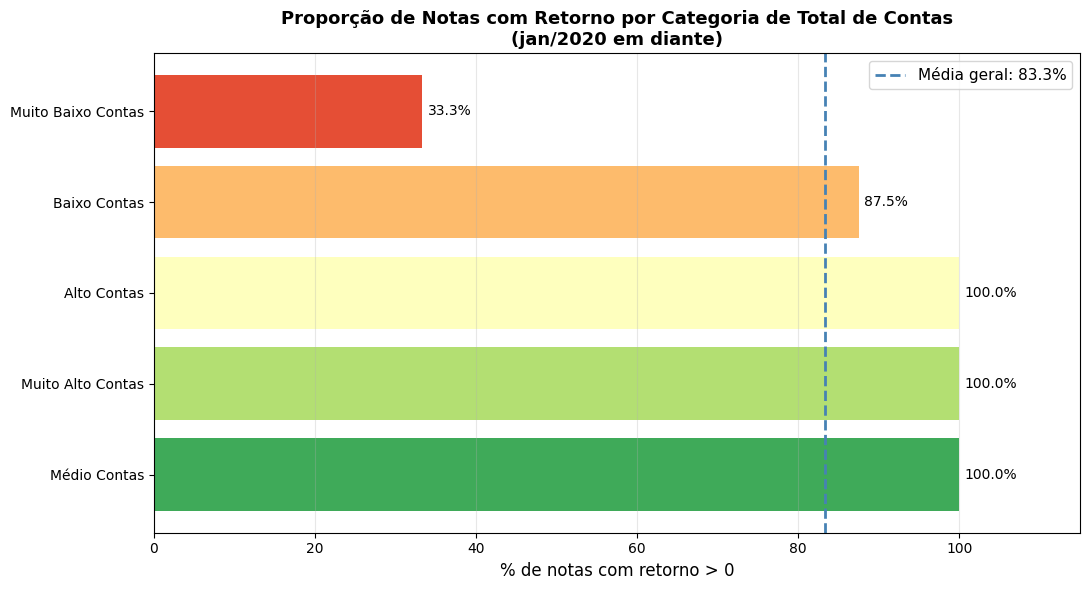

In [ ]:
# Criação de categorias para 'total_contas' usando quantis

# Remove zeros para evitar problemas com quantis em dados muito esparsos no limite inferior
df_temp_total_contas = df[df['total_contas'] > 0].copy()

# Define os rótulos para as categorias
labels_total_contas = ['Muito Baixo Contas', 'Baixo Contas', 'Médio Contas', 'Alto Contas', 'Muito Alto Contas']

try:
    # Passo 1: Obter o IntervalIndex e os bins numéricos
    _, cut_bins_total_contas = pd.qcut(
        df['total_contas'],
        q=5, # 5 quantis
        retbins=True,
        duplicates='drop'
    )
    # Garante que o primeiro bin comece de -inf para cobrir todos os valores, e o último em +inf
    cut_bins_total_contas[0] = -np.inf
    cut_bins_total_contas[-1] = np.inf

    # Passo 2: Aplicar os bins e labels explicitamente com pd.cut
    df['total_contas_categoria'] = pd.cut(
        df['total_contas'],
        bins=cut_bins_total_contas,
        labels=labels_total_contas,
        include_lowest=True,
        right=True
    )
    # Salvar os bins e labels capturados para deployment em variáveis globais
    global bins_total_contas_categoria_global, labels_total_contas_categoria_global
    bins_total_contas_categoria_global = cut_bins_total_contas
    labels_total_contas_categoria_global = labels_total_contas

except Exception as e:
    print(f"Não foi possível criar 5 quantis únicos para 'total_contas'. Tentando com menos quantis ou binarização. Erro: {e}")
    df['total_contas_categoria'] = pd.cut(
        df['total_contas'],
        bins=pd.IntervalIndex.from_breaks([-np.inf, df['total_contas'].median(), np.inf]),
        labels=['Abaixo da Mediana Contas', 'Acima da Mediana Contas']
    )
    bins_total_contas_categoria_global = np.array([-np.inf, df['total_contas'].median(), np.inf])
    labels_total_contas_categoria_global = ['Abaixo da Mediana Contas', 'Acima da Mediana Contas']

col_cat_total_contas = 'total_contas_categoria'

print(f"\nNova coluna categórica '{col_cat_total_contas}' criada com base em 'total_contas'.")
print("Distribuição das novas categorias:")
print(df[col_cat_total_contas].value_counts())

proporcao_total_contas = (
    df.groupby(col_cat_total_contas)['flag_credito']
    .agg(total='count', eventos='sum')
    .assign(pct_retorno=lambda x: x['eventos'] / x['total'] * 100)
    .sort_values('pct_retorno', ascending=False)
    .reset_index()
)

print("\n" + "=" * 65)
print("PROPORÇÃO DE NOTAS COM RETORNO > 0 POR CATEGORIA DE TOTAL DE CONTAS")
print("=" * 65)
print(proporcao_total_contas.to_string(index=False))

# Gráfico de proporção
fig, ax = plt.subplots(figsize=(11, 6))
cores = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(proporcao_total_contas)))
bars = ax.barh(proporcao_total_contas[col_cat_total_contas], proporcao_total_contas['pct_retorno'], color=cores[::-1])

# Linha da média geral
media_geral = df['flag_credito'].sum() / len(df) * 100 # Recalcula média geral, caso tenha sido sobrescrita
ax.axvline(media_geral, color='steelblue', linestyle='--', linewidth=2,
           label=f'Média geral: {media_geral:.1f}%')

ax.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=10)
ax.set_xlabel('% de notas com retorno > 0', fontsize=12)
ax.set_title('Proporção de Notas com Retorno por Categoria de Total de Contas\n(jan/2020 em diante)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xlim(0, proporcao_total_contas['pct_retorno'].max() * 1.15)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()


TABELA WOE POR CATEGORIA DE TOTAL DE CONTAS
total_contas_categoria  total  eventos  nao_eventos  pct_retorno  dist_eventos  dist_nao_ev     WOE  IV_parcial
     Muito Alto Contas      9        9            0     100.0000        0.2571       0.0000  1.3350      0.3433
           Alto Contas      8        8            0     100.0000        0.2286       0.0000  1.2238      0.2797
          Médio Contas      8        8            0     100.0000        0.2286       0.0000  1.2238      0.2797
          Baixo Contas      8        7            1      87.5000        0.2000       0.1429  0.0000      0.0000
    Muito Baixo Contas      9        3            6      33.3333        0.0857       0.8571 -2.2285      1.7191


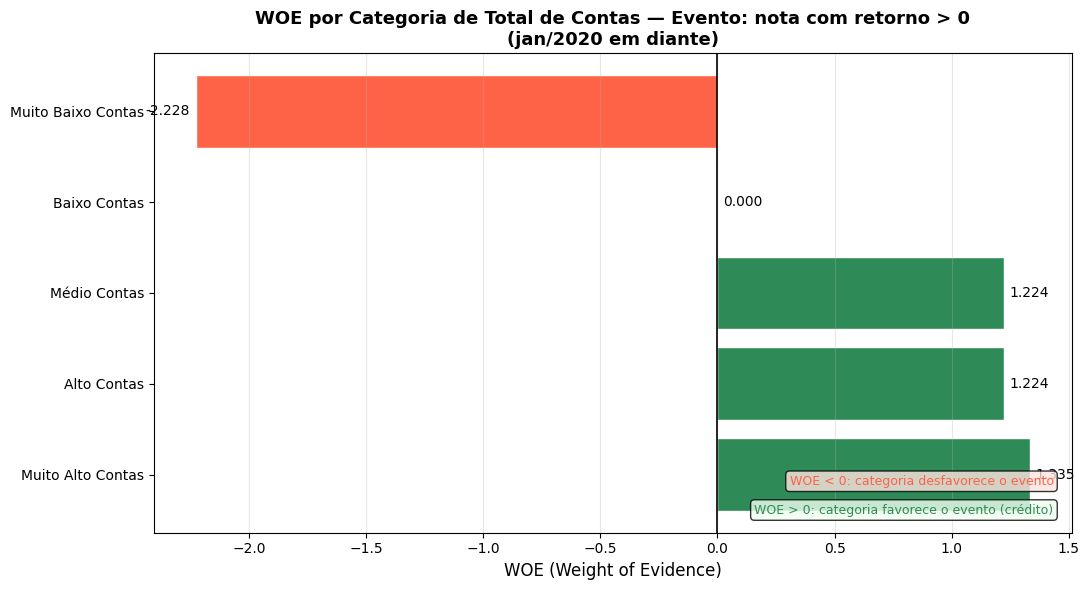

In [ ]:
# Cálculo do WOE para 'total_contas_categoria'
eps = 0.5

woe_df_total_contas = (
    df.groupby(col_cat_total_contas)['flag_credito']
    .agg(eventos='sum', total='count')
    .reset_index()
)
woe_df_total_contas['nao_eventos']  = woe_df_total_contas['total'] - woe_df_total_contas['eventos']
woe_df_total_contas['pct_retorno']  = woe_df_total_contas['eventos'] / woe_df_total_contas['total'] * 100

n_eventos_total = df['flag_credito'].sum()
n_nao_ev_total = len(df) - n_eventos_total

woe_df_total_contas['dist_eventos'] = woe_df_total_contas['eventos'] / n_eventos_total
woe_df_total_contas['dist_nao_ev']  = woe_df_total_contas['nao_eventos'] / n_nao_ev_total

woe_df_total_contas['WOE'] = np.log(
    (woe_df_total_contas['eventos'] + eps) / n_eventos_total /
    ((woe_df_total_contas['nao_eventos'] + eps) / n_nao_ev_total)
)

woe_df_total_contas['IV_parcial'] = (woe_df_total_contas['dist_eventos'] - woe_df_total_contas['dist_nao_ev']) * woe_df_total_contas['WOE']
woe_df_total_contas = woe_df_total_contas.sort_values('WOE', ascending=False).reset_index(drop=True)

print("\n" + "=" * 80)
print("TABELA WOE POR CATEGORIA DE TOTAL DE CONTAS")
print("=" * 80)
colunas_exibir_total_contas = [col_cat_total_contas, 'total', 'eventos', 'nao_eventos',
                  'pct_retorno', 'dist_eventos', 'dist_nao_ev', 'WOE', 'IV_parcial']
print(woe_df_total_contas[colunas_exibir_total_contas].to_string(index=False, float_format='%.4f'))

# Gráfico WOE
fig, ax = plt.subplots(figsize=(11, 6))
cores_woe = ['seagreen' if w >= 0 else 'tomato' for w in woe_df_total_contas['WOE']]
bars_woe  = ax.barh(woe_df_total_contas[col_cat_total_contas], woe_df_total_contas['WOE'], color=cores_woe, edgecolor='white')

ax.axvline(0, color='black', linewidth=1.2)
ax.bar_label(bars_woe, fmt='%.3f', padding=4, fontsize=10)
ax.set_xlabel('WOE (Weight of Evidence)', fontsize=12)
ax.set_title('WOE por Categoria de Total de Contas — Evento: nota com retorno > 0\n(jan/2020 em diante)',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

ax.annotate('WOE > 0: categoria favorece o evento (crédito)',
            xy=(0.98, 0.04), xycoords='axes fraction',
            ha='right', fontsize=9, color='seagreen',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='honeydew', alpha=0.8))
ax.annotate('WOE < 0: categoria desfavorece o evento',
            xy=(0.98, 0.10), xycoords='axes fraction',
            ha='right', fontsize=9, color='tomato',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='mistyrose', alpha=0.8))

plt.tight_layout()
plt.show()


INFORMATION VALUE (IV) PARA TOTAL DE CONTAS

  IV Total = 2.6218
  Interpretação: Poder preditivo MUITO FORTE (verificar)

  IV por categoria (contribuição parcial):
  Muito Alto Contas           0.3433  ████████████████████████████████████████████████████████████████████
  Alto Contas                 0.2797  ███████████████████████████████████████████████████████
  Médio Contas                0.2797  ███████████████████████████████████████████████████████
  Baixo Contas                0.0000  █
  Muito Baixo Contas          1.7191  ███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████


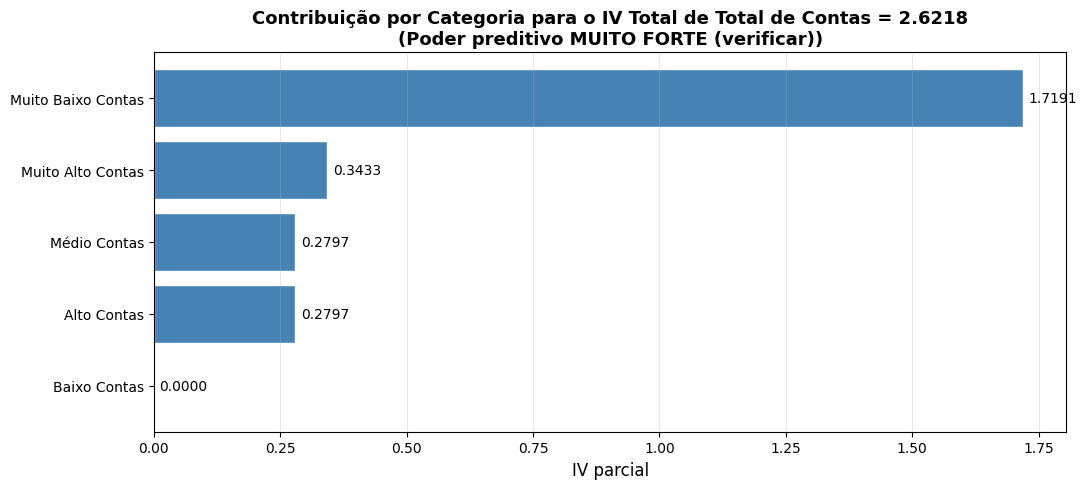

In [ ]:
# Cálculo do Information Value (IV) para 'total_contas_categoria'
IV_total_total_contas = woe_df_total_contas['IV_parcial'].sum()

print("\n" + "=" * 55)
print("INFORMATION VALUE (IV) PARA TOTAL DE CONTAS")
print("=" * 55)
print(f"\n  IV Total = {IV_total_total_contas:.4f}")
print(f"  Interpretação: {interpretar_iv(IV_total_total_contas)}") # Reusing the interpretar_iv function
print("\n  IV por categoria (contribuição parcial):")
for _, row in woe_df_total_contas.iterrows():
    barra = '█' * max(1, int(abs(row['IV_parcial']) * 200))
    print(f"  {row[col_cat_total_contas]:<25} {row['IV_parcial']:>8.4f}  {barra}")

# Gráfico IV parcial
fig, ax = plt.subplots(figsize=(11, 5))
iv_plot = woe_df_total_contas.sort_values('IV_parcial')
ax.barh(iv_plot[col_cat_total_contas], iv_plot['IV_parcial'],
        color='steelblue', edgecolor='white')
ax.bar_label(ax.containers[0], fmt='%.4f', padding=4, fontsize=10)
ax.set_xlabel('IV parcial', fontsize=12)
ax.set_title(f'Contribuição por Categoria para o IV Total de Total de Contas = {IV_total_total_contas:.4f}\n'
             f'({interpretar_iv(IV_total_total_contas)})',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

In [ ]:
# Seleciona apenas as colunas numéricas para calcular a correlação
# Exclui a coluna 'flag_credito' para calcular a correlação entre as features
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Considerando que 'flag_credito' é a variável alvo, podemos analisar sua correlação separadamente
# ou incluí-la na matriz geral se desejado para ver a correlação com as features.
# Para este propósito, vamos incluir todas as numéricas e observar.

correlation_matrix = df[numerical_cols].corr()

print("Matriz de Correlação:")
display(correlation_matrix)


Matriz de Correlação:


,total_contas,valor_cancelamento,flag_credito
total_contas,1.000000,0.995151,0.124222
valor_cancelamento,0.995151,1.000000,0.142779
flag_credito,0.124222,0.142779,1.000000


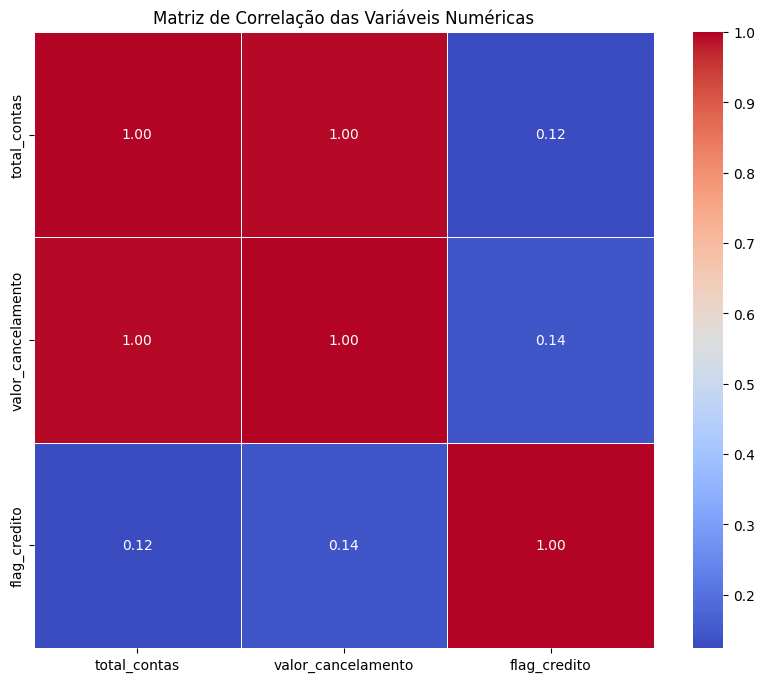

In [ ]:
# Visualiza a matriz de correlação usando um heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlação das Variáveis Numéricas')
plt.show()


In [ ]:
print("""
╔══════════════════════════════════════════════════════════╗
║        CONCLUSÕES E INSIGHTS — M36                      ║
║   Modelagem de Dados Categorizados | NFP / AMA          ║
╚══════════════════════════════════════════════════════════╝
""")

# Melhor e pior categoria
# Verifica se woe_df e col_cat estão definidos antes de usá-los
if 'woe_df' in globals() and 'col_cat' in globals() and not woe_df.empty:
    melhor_cat = woe_df.iloc[0]
    pior_cat   = woe_df.iloc[-1]

    print(f"""━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 1. ANÁLISE DE PROPORÇÃO POR CATEGORIA
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 • A proporção de notas com retorno varia significativamente
   entre as categorias de estabelecimento.
 • Categoria com MAIOR proporção de retorno:
   → {melhor_cat[col_cat]} ({melhor_cat['pct_retorno']:.1f}% das notas geram crédito)
 • Categoria com MENOR proporção de retorno:
   → {pior_cat[col_cat]} ({pior_cat['pct_retorno']:.1f}% das notas geram crédito)
 • Essa variação sugere que o tipo de estabelecimento
   influencia diretamente a probabilidade de geração de crédito.
   Estabelecimentos com produtos incentivados (alimentos,
   medicamentos) tendem a ter maior retorno.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 2. WOE — WEIGHT OF EVIDENCE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 • WOE mede o quanto cada categoria "pende" para o evento
   (crédito > 0) em relação ao não-evento.
 • WOE > 0: categoria está acima da média → favorece crédito
 • WOE < 0: categoria está abaixo da média → desfavorece
 • WOE = 0: categoria tem comportamento igual à média geral

 • Categorias com WOE mais positivo: estabelecimentos onde
   predominam produtos com incidência de ICMS (supermercados,
   farmácias, padarias).
 • Categorias com WOE mais negativo: estabelecimentos com
   produtos não incentivados ou isentos de ICMS (postos de
   combustível, tabacarias, bebidas alcoólicas).

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 3. INFORMATION VALUE (IV)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━""")

    if 'IV_total' in globals():
        print(f" • IV Total calculado: {IV_total:.4f}")
        print(f" • Interpretação: {interpretar_iv(IV_total)}")
    else:
        print(" • IV Total não calculado. Certifique-se de que o WOE e IV foram calculados corretamente nas etapas anteriores.")

    print("""
 • O IV quantifica o poder preditivo GLOBAL da variável
   'categoria' para prever se a nota vai gerar crédito.
 • Categorias com maior IV parcial são as que mais
   contribuem para diferenciar notas com e sem retorno.
 • A variável 'categoria' pode ser utilizada em modelos
   de classificação (ex: regressão logística) para prever
   a probabilidade de uma nota gerar crédito para a AMA.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 4. CONTEXTO DO NEGÓCIO — AMA / NFP
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 • Esta análise tem impacto direto nas estratégias de
   captação de recursos para a Associação de Amigos do Autista.
 • Conhecer quais categorias geram mais crédito permite:
   → Comunicação direcionada: incentivar doadores a comprar
     em estabelecimentos com maior taxa de retorno.
   → Priorizar parcerias com categorias de alto WOE.
   → Identificar estabelecimentos "sem retorno" para
     entender se há questões de cadastro ou de produtos.

 • A variabilidade difícil de explicar mencionada no enunciado
   é esperada e reflete:
   → Produtos não incentivados (cigarro, bebidas alcoólicas)
   → Informações protegidas por LGPD não disponíveis
   → Frequência irregular de emissão de notas

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 5. PRÓXIMOS PASSOS SUGERIDOS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 a) Usar o WOE calculado para substituir as categorias
    na modelagem → transforma categórica em numérica
    com poder preditivo embutido.
 b) Calcular WOE/IV para outras variáveis (ex: emitente,
    faixa de valor da nota) e combinar num modelo logístico.
 c) Analisar evolução temporal do WOE para identificar
    se o poder preditivo das categorias mudou ao longo do
    programa NFP.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")
else:
    print("Não foi possível gerar as conclusões pois 'woe_df' ou 'col_cat' não foram definidos ou estão vazios. Por favor, execute as células anteriores.")


╔══════════════════════════════════════════════════════════╗
║        CONCLUSÕES E INSIGHTS — M36                      ║
║   Modelagem de Dados Categorizados | NFP / AMA          ║
╚══════════════════════════════════════════════════════════╝

Não foi possível gerar as conclusões pois 'woe_df' ou 'col_cat' não foram definidos ou estão vazios. Por favor, execute as células anteriores.


## Distribuição de 'valor_cancelamento' por 'flag_credito'

Vamos visualizar a distribuição do `valor_cancelamento` (valor do cancelamento) para entender como ele se comporta entre as notas que geram crédito (`flag_credito = 1`) e as que não geram (`flag_credito = 0`). Um gráfico de violino é ideal para isso, pois mostra a densidade da distribuição, a mediana e os quartis.

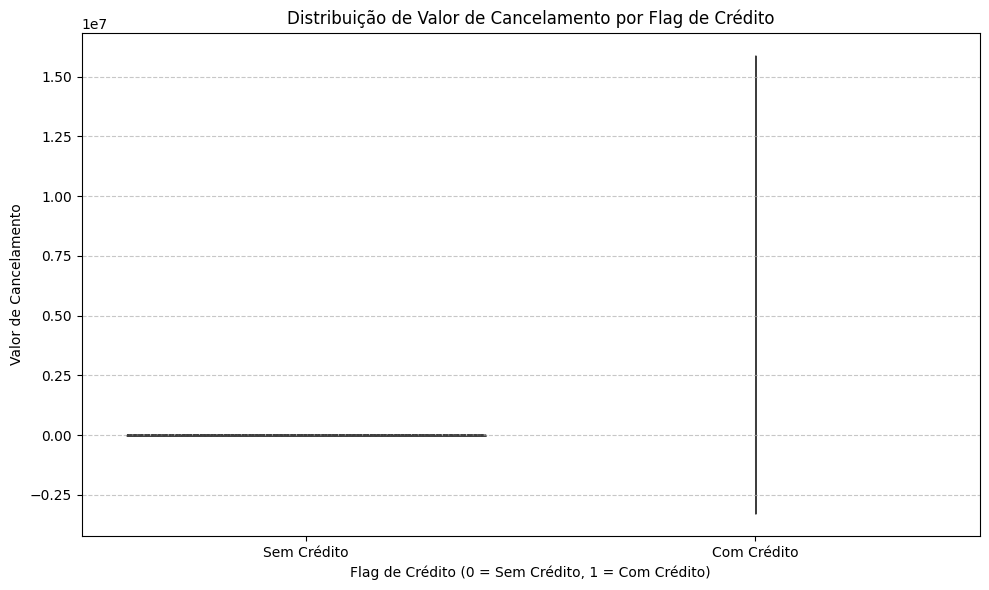

In [ ]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='flag_credito', y='valor_cancelamento', data=df, inner='quartile')
plt.title('Distribuição de Valor de Cancelamento por Flag de Crédito')
plt.xlabel('Flag de Crédito (0 = Sem Crédito, 1 = Com Crédito)')
plt.ylabel('Valor de Cancelamento')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks([0, 1], ['Sem Crédito', 'Com Crédito'])
plt.tight_layout()
plt.show()


## Criação e Avaliação de Modelo de Regressão Logística

Vamos construir um modelo de Regressão Logística para prever a flag_credito utilizando a variável categoria criada, que já foi transformada em seus valores de Weight of Evidence (WOE). O WOE é uma ótima maneira de representar variáveis categóricas em modelos de regressão, pois ele captura a relação log-odds entre a categoria e a variável alvo.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preparar os dados para o modelo
# Mapear 'categoria_criada' para seus valores WOE
# Certifique-se de que woe_df e col_cat estão disponíveis do passo anterior
if 'woe_df' in globals() and 'col_cat' in globals() and not woe_df.empty:
    woe_map = woe_df.set_index(col_cat)['WOE'].to_dict()
    df['categoria_criada_WOE'] = df[col_cat].map(woe_map)

    # Verificar se há NaNs após o mapeamento (pode ocorrer se houver categorias no df que não estão no woe_df)
    if df['categoria_criada_WOE'].isnull().any():
        print("Atenção: Existem categorias em 'categoria_criada' que não foram encontradas no woe_df. Preenchendo NaNs com 0.")
        df['categoria_criada_WOE'] = df['categoria_criada_WOE'].fillna(0)

    # Definir X (features) e y (target)
    X = df[['categoria_criada_WOE']]
    y = df['flag_credito']

    print("Variáveis para o modelo definidas:")
    print(f"X (features) shape: {X.shape}")
    print(f"y (target) shape: {y.shape}")
    print(X.head())
    print(y.head())

else:
    print("Erro: 'woe_df' ou 'col_cat' não encontrados. Certifique-se de que as células anteriores foram executadas corretamente.")


Variáveis para o modelo definidas:
X (features) shape: (42, 1)
y (target) shape: (42,)
   categoria_criada_WOE
0              1.223775
1             -2.708050
2              1.223775
3              1.223775
4              1.223775
0    1
1    0
2    1
3    1
4    1
Name: flag_credito, dtype: int64


In [ ]:
# 2. Dividir os dados em conjuntos de treino e teste
# Usaremos 70% dos dados para treino e 30% para teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Tamanho do conjunto de treino (X_train): {X_train.shape}")
print(f"Tamanho do conjunto de teste (X_test): {X_test.shape}")
print(f"Distribuição da flag_credito no treino:\n{y_train.value_counts(normalize=True)}")
print(f"Distribuição da flag_credito no teste:\n{y_test.value_counts(normalize=True)}")


Tamanho do conjunto de treino (X_train): (29, 1)
Tamanho do conjunto de teste (X_test): (13, 1)
Distribuição da flag_credito no treino:
flag_credito
1    0.827586
0    0.172414
Name: proportion, dtype: float64
Distribuição da flag_credito no teste:
flag_credito
1    0.846154
0    0.153846
Name: proportion, dtype: float64


In [ ]:
# 3. Treinar o modelo de Regressão Logística
model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' é bom para pequenos datasets
model.fit(X_train, y_train)

print("Modelo de Regressão Logística treinado com sucesso!")
print(f"Coeficiente (WOE): {model.coef_[0][0]:.4f}")
print(f"Intercept: {model.intercept_[0]:.4f}")


Modelo de Regressão Logística treinado com sucesso!
Coeficiente (WOE): 0.9741
Intercept: 1.5450



Relatório de Classificação no Conjunto de Teste
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00        11

    accuracy                           1.00        13
   macro avg       1.00      1.00      1.00        13
weighted avg       1.00      1.00      1.00        13

AUC ROC Score: 1.0000


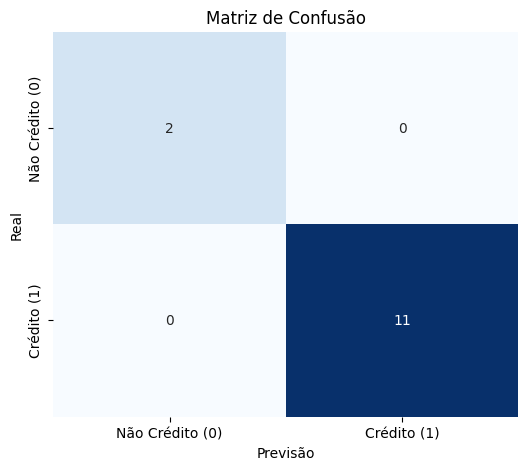

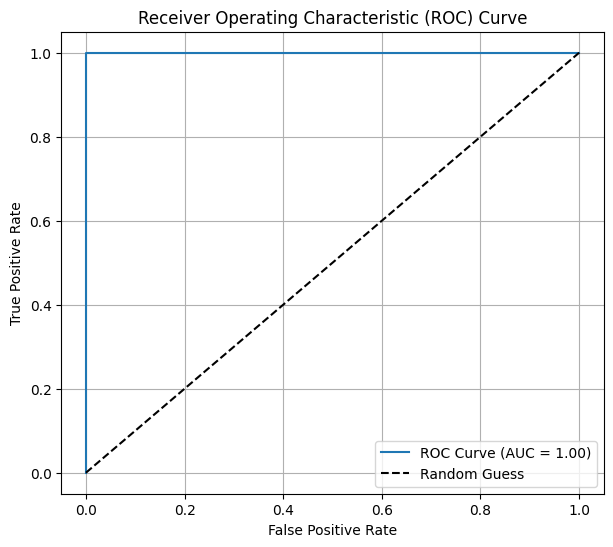

In [ ]:
# 4. Avaliar o desempenho do modelo

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1] # Probabilidade da classe positiva (flag_credito = 1)

print("\n" + "=" * 50)
print("Relatório de Classificação no Conjunto de Teste")
print("=" * 50)
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC ROC Score: {roc_auc:.4f}")

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Não Crédito (0)', 'Crédito (1)'],
            yticklabels=['Não Crédito (0)', 'Crédito (1)'])
plt.title('Matriz de Confusão')
plt.xlabel('Previsão')
plt.ylabel('Real')
plt.show()

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


## 8. Expandindo o Modelo de Regressão Logística com `total_contas_categoria_WOE`

Agora que analisamos o poder preditivo de `total_contas` através do WOE e IV, vamos adicionar esta variável (transformada em WOE) ao nosso modelo de Regressão Logística para ver como ela melhora o desempenho do modelo.

In [ ]:
# 1. Preparar os dados para o modelo (com a nova variável)

# Mapear 'total_contas_categoria' para seus valores WOE
# Certifique-se de que woe_df_total_contas e col_cat_total_contas estão disponíveis
if 'woe_df_total_contas' in globals() and 'col_cat_total_contas' in globals() and not woe_df_total_contas.empty:
    woe_map_total_contas = woe_df_total_contas.set_index(col_cat_total_contas)['WOE'].to_dict()
    df['total_contas_categoria_WOE'] = df[col_cat_total_contas].map(woe_map_total_contas)

    # Verificar se há NaNs após o mapeamento
    if df['total_contas_categoria_WOE'].isnull().any():
        print("Atenção: Existem categorias em 'total_contas_categoria' que não foram encontradas no woe_df_total_contas. Preenchendo NaNs com 0.")
        df['total_contas_categoria_WOE'] = df['total_contas_categoria_WOE'].fillna(0)

    # Definir X (features) e y (target) com ambas as variáveis WOE
    X_expanded = df[['categoria_criada_WOE', 'total_contas_categoria_WOE']]
    y_expanded = df['flag_credito']

    print("Variáveis para o modelo expandido definidas:")
    print(f"X (features) shape: {X_expanded.shape}")
    print(f"y (target) shape: {y_expanded.shape}")
    print(X_expanded.head())
    print(y_expanded.head())

else:
    print("Erro: 'woe_df_total_contas' ou 'col_cat_total_contas' não encontrados. Certifique-se de que as células anteriores foram executadas corretamente.")

Variáveis para o modelo expandido definidas:
X (features) shape: (42, 2)
y (target) shape: (42,)
   categoria_criada_WOE  total_contas_categoria_WOE
0              1.223775                    1.223775
1             -2.708050                   -2.228477
2              1.223775                    1.223775
3              1.223775                    0.000000
4              1.223775                    1.223775
0    1
1    0
2    1
3    1
4    1
Name: flag_credito, dtype: int64


In [ ]:
# 2. Dividir os dados em conjuntos de treino e teste (para o modelo expandido)
# Usaremos a mesma divisão estratégica para garantir consistência
X_train_expanded, X_test_expanded, y_train_expanded, y_test_expanded = train_test_split(X_expanded, y_expanded, test_size=0.3, random_state=42, stratify=y_expanded)

print(f"Tamanho do conjunto de treino expandido (X_train_expanded): {X_train_expanded.shape}")
print(f"Tamanho do conjunto de teste expandido (X_test_expanded): {X_test_expanded.shape}")
print(f"Distribuição da flag_credito no treino expandido:\n{y_train_expanded.value_counts(normalize=True)}")
print(f"Distribuição da flag_credito no teste expandido:\n{y_test_expanded.value_counts(normalize=True)}")

Tamanho do conjunto de treino expandido (X_train_expanded): (29, 2)
Tamanho do conjunto de teste expandido (X_test_expanded): (13, 2)
Distribuição da flag_credito no treino expandido:
flag_credito
1    0.827586
0    0.172414
Name: proportion, dtype: float64
Distribuição da flag_credito no teste expandido:
flag_credito
1    0.846154
0    0.153846
Name: proportion, dtype: float64


In [ ]:
# 3. Treinar o modelo de Regressão Logística expandido
model_expanded = LogisticRegression(random_state=42, solver='liblinear')
model_expanded.fit(X_train_expanded, y_train_expanded)

print("Modelo de Regressão Logística expandido treinado com sucesso!")
print("Coeficientes (WOE):")
for feature, coef in zip(X_expanded.columns, model_expanded.coef_[0]):
    print(f"  {feature}: {coef:.4f}")
print(f"Intercept: {model_expanded.intercept_[0]:.4f}")

Modelo de Regressão Logística expandido treinado com sucesso!
Coeficientes (WOE):
  categoria_criada_WOE: 0.9857
  total_contas_categoria_WOE: -0.0183
Intercept: 1.5438



Relatório de Classificação do Modelo Expandido no Conjunto de Teste
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00        11

    accuracy                           1.00        13
   macro avg       1.00      1.00      1.00        13
weighted avg       1.00      1.00      1.00        13

AUC ROC Score (Expandido): 1.0000


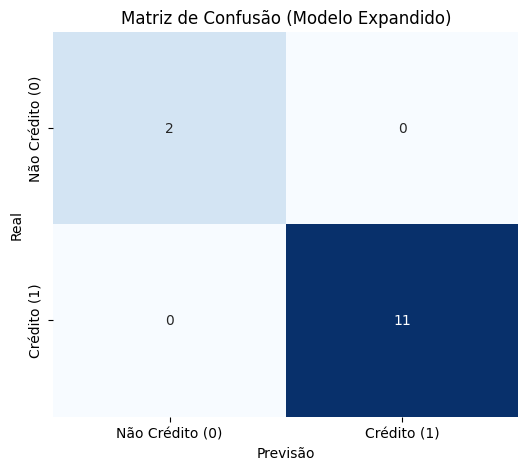

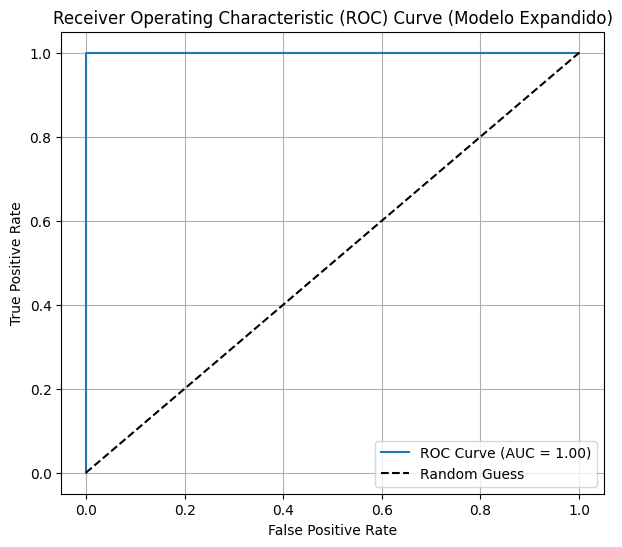

In [ ]:
# 4. Avaliar o desempenho do modelo expandido

y_pred_expanded = model_expanded.predict(X_test_expanded)
y_pred_proba_expanded = model_expanded.predict_proba(X_test_expanded)[:, 1] # Probabilidade da classe positiva (flag_credito = 1)

print("\n" + "=" * 60)
print("Relatório de Classificação do Modelo Expandido no Conjunto de Teste")
print("=" * 60)
print(classification_report(y_test_expanded, y_pred_expanded))

roc_auc_expanded = roc_auc_score(y_test_expanded, y_pred_proba_expanded)
print(f"AUC ROC Score (Expandido): {roc_auc_expanded:.4f}")

# Matriz de Confusão
cm_expanded = confusion_matrix(y_test_expanded, y_pred_expanded)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_expanded, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Não Crédito (0)', 'Crédito (1)'],
            yticklabels=['Não Crédito (0)', 'Crédito (1)'])
plt.title('Matriz de Confusão (Modelo Expandido)')
plt.xlabel('Previsão')
plt.ylabel('Real')
plt.show()

# Curva ROC
fpr_expanded, tpr_expanded, thresholds_expanded = roc_curve(y_test_expanded, y_pred_proba_expanded)
plt.figure(figsize=(7, 6))
plt.plot(fpr_expanded, tpr_expanded, label=f'ROC Curve (AUC = {roc_auc_expanded:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (Modelo Expandido)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## 9. Validação Cruzada (K-Fold Estratificada) para Avaliar Risco de Overfitting

Dado o desempenho perfeito do modelo, é crucial realizar uma validação cruzada para entender melhor sua robustez e avaliar o risco de *overfitting*. Usaremos a validação cruzada K-Fold estratificada para garantir que a proporção das classes seja mantida em cada fold, o que é importante em datasets com desbalanceamento de classes.

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Definir o número de folds (K)
# Geralmente 5 ou 10 são valores comuns. Com um dataset pequeno, 3 ou 5 podem ser mais adequados.
# Ajustaremos para K=3 ou K=5, considerando o tamanho reduzido do dataset (42 amostras no total).
# Se o número de splits for maior que o número de amostras da menor classe, pode dar erro.
# A classe minoritária tem 7 amostras (0), então K deve ser <= 7.

n_splits = 3 # Definir K para 3 folds para garantir que haja pelo menos 2 amostras da classe minoritária em cada fold (7 * 0.7 = 4.9, 7 * 0.3 = 2.1)

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Listas para armazenar as métricas de cada fold
accuracies = []
precisions = []
recalls = []
f1_scores = []
roc_aucs = []

print(f"Iniciando Validação Cruzada com {n_splits} Folds Estratificados...")

# Loop pelos folds
for fold, (train_index, test_index) in enumerate(skf.split(X_expanded, y_expanded)):
    print(f"\n--- Fold {fold + 1}/{n_splits} ---")

    # Dividir os dados para o fold atual
    X_train_fold, X_test_fold = X_expanded.iloc[train_index], X_expanded.iloc[test_index]
    y_train_fold, y_test_fold = y_expanded.iloc[train_index], y_expanded.iloc[test_index]

    # Treinar o modelo
    model_fold = LogisticRegression(random_state=42, solver='liblinear')
    model_fold.fit(X_train_fold, y_train_fold)

    # Fazer previsões
    y_pred_fold = model_fold.predict(X_test_fold)
    y_pred_proba_fold = model_fold.predict_proba(X_test_fold)[:, 1]

    # Calcular e armazenar as métricas
    accuracies.append(accuracy_score(y_test_fold, y_pred_fold))
    precisions.append(precision_score(y_test_fold, y_pred_fold, zero_division=0))
    recalls.append(recall_score(y_test_fold, y_pred_fold, zero_division=0))
    f1_scores.append(f1_score(y_test_fold, y_pred_fold, zero_division=0))
    roc_aucs.append(roc_auc_score(y_test_fold, y_pred_proba_fold))

    print(f"  Acurácia: {accuracies[-1]:.4f}")
    print(f"  Precisão: {precisions[-1]:.4f}")
    print(f"  Recall: {recalls[-1]:.4f}")
    print(f"  F1-Score: {f1_scores[-1]:.4f}")
    print(f"  AUC ROC: {roc_aucs[-1]:.4f}")

# Apresentar as métricas médias e desvio padrão
print("\n" + "=" * 50)
print("MÉTRICAS MÉDIAS DA VALIDAÇÃO CRUZADA")
print("=" * 50)
print(f"Média Acurácia: {np.mean(accuracies):.4f} (Std: {np.std(accuracies):.4f})")
print(f"Média Precisão: {np.mean(precisions):.4f} (Std: {np.std(precisions):.4f})")
print(f"Média Recall: {np.mean(recalls):.4f} (Std: {np.std(recalls):.4f})")
print(f"Média F1-Score: {np.mean(f1_scores):.4f} (Std: {np.std(f1_scores):.4f})")
print(f"Média AUC ROC: {np.mean(roc_aucs):.4f} (Std: {np.std(roc_aucs):.4f})")
print("=" * 50)

Iniciando Validação Cruzada com 3 Folds Estratificados...

--- Fold 1/3 ---
  Acurácia: 0.9286
  Precisão: 1.0000
  Recall: 0.9167
  F1-Score: 0.9565
  AUC ROC: 0.9375

--- Fold 2/3 ---
  Acurácia: 0.9286
  Precisão: 1.0000
  Recall: 0.9167
  F1-Score: 0.9565
  AUC ROC: 0.9583

--- Fold 3/3 ---
  Acurácia: 1.0000
  Precisão: 1.0000
  Recall: 1.0000
  F1-Score: 1.0000
  AUC ROC: 1.0000

MÉTRICAS MÉDIAS DA VALIDAÇÃO CRUZADA
Média Acurácia: 0.9524 (Std: 0.0337)
Média Precisão: 1.0000 (Std: 0.0000)
Média Recall: 0.9444 (Std: 0.0393)
Média F1-Score: 0.9710 (Std: 0.0205)
Média AUC ROC: 0.9653 (Std: 0.0260)


In [ ]:
import joblib
import os
import pandas as pd # Importar pandas para pd.IntervalIndex
import numpy as np # Importar numpy para np.inf, se usado nos bins

# Criar diretório para salvar os artefatos, se não existir
output_dir = 'model_artifacts'
os.makedirs(output_dir, exist_ok=True)

# 1. Salvar o modelo treinado
model_filename = os.path.join(output_dir, 'logistic_regression_model.joblib')
joblib.dump(model_expanded, model_filename)
print(f"Modelo salvo em: {model_filename}")

# 2. Salvar os dicionários de mapeamento WOE
woe_map_filename = os.path.join(output_dir, 'woe_map_categoria_criada.joblib')
joblib.dump(woe_map, woe_map_filename)
print(f"Mapa WOE de 'categoria_criada' salvo em: {woe_map_filename}")

woe_map_total_contas_filename = os.path.join(output_dir, 'woe_map_total_contas_categoria.joblib')
joblib.dump(woe_map_total_contas, woe_map_total_contas_filename)
print(f"Mapa WOE de 'total_contas_categoria' salvo em: {woe_map_total_contas_filename}")

# 3. Salvar os bins e labels usados para a categorização (pd.cut)
# As variáveis globais 'bins_categoria_criada_global', 'labels_categoria_criada_global', etc.
# são definidas nas células de criação de categoria (UVmPS0BeOCH2 e 8a98fbb6).

joblib.dump(bins_categoria_criada_global, os.path.join(output_dir, 'bins_categoria_criada.joblib'))
joblib.dump(labels_categoria_criada_global, os.path.join(output_dir, 'labels_categoria_criada.joblib'))
print(f"Bins e labels de 'categoria_criada' salvos em: {os.path.join(output_dir, 'bins_categoria_criada.joblib')} e {os.path.join(output_dir, 'labels_categoria_criada.joblib')}")

joblib.dump(bins_total_contas_categoria_global, os.path.join(output_dir, 'bins_total_contas_categoria.joblib'))
joblib.dump(labels_total_contas_categoria_global, os.path.join(output_dir, 'labels_total_contas_categoria.joblib'))
print(f"Bins e labels de 'total_contas_categoria' salvos em: {os.path.join(output_dir, 'bins_total_contas_categoria.joblib')} e {os.path.join(output_dir, 'labels_total_contas_categoria.joblib')}")

Modelo salvo em: model_artifacts/logistic_regression_model.joblib
Mapa WOE de 'categoria_criada' salvo em: model_artifacts/woe_map_categoria_criada.joblib
Mapa WOE de 'total_contas_categoria' salvo em: model_artifacts/woe_map_total_contas_categoria.joblib
Bins e labels de 'categoria_criada' salvos em: model_artifacts/bins_categoria_criada.joblib e model_artifacts/labels_categoria_criada.joblib
Bins e labels de 'total_contas_categoria' salvos em: model_artifacts/bins_total_contas_categoria.joblib e model_artifacts/labels_total_contas_categoria.joblib


In [ ]:
import joblib
import pandas as pd
import numpy as np # Importar numpy para np.inf

# Carregar os artefatos
loaded_model = joblib.load('model_artifacts/logistic_regression_model.joblib')
loaded_woe_map = joblib.load('model_artifacts/woe_map_categoria_criada.joblib')
loaded_woe_map_total_contas = joblib.load('model_artifacts/woe_map_total_contas_categoria.joblib')

# Carregar os bins e labels para categorização consistente
loaded_bins_categoria_criada = joblib.load('model_artifacts/bins_categoria_criada.joblib')
loaded_labels_categoria_criada = joblib.load('model_artifacts/labels_categoria_criada.joblib')

loaded_bins_total_contas_categoria = joblib.load('model_artifacts/bins_total_contas_categoria.joblib')
loaded_labels_total_contas_categoria = joblib.load('model_artifacts/labels_total_contas_categoria.joblib')

print("Artefatos carregados com sucesso!")

# Simular novos dados (por exemplo, uma nova nota fiscal)
# Assumimos que 'valor_cancelamento' e 'total_contas' são as entradas brutas
new_data = pd.DataFrame({
    'valor_cancelamento': [1500, 50, 10000, 25000, 100, 50000],
    'total_contas': [50, 5, 200, 500, 15, 1000]
})

print("\nNovos dados de entrada:")
display(new_data)

# Pré-processamento dos novos dados (aplicar as mesmas transformações)

# 1. Categorizar 'valor_cancelamento' para 'categoria_criada' usando os bins salvos
new_data['categoria_criada_pred'] = pd.cut(
    new_data['valor_cancelamento'],
    bins=loaded_bins_categoria_criada,
    labels=loaded_labels_categoria_criada,
    include_lowest=True, # Incluir o valor mais baixo no primeiro bin
    right=True # Intervalos fechados à direita (padrão)
)

# 2. Categorizar 'total_contas' para 'total_contas_categoria' usando os bins salvos
new_data['total_contas_categoria_pred'] = pd.cut(
    new_data['total_contas'],
    bins=loaded_bins_total_contas_categoria,
    labels=loaded_labels_total_contas_categoria,
    include_lowest=True, # Incluir o valor mais baixo no primeiro bin
    right=True # Intervalos fechados à direita (padrão)
)

# Mapear para WOE
new_data['categoria_criada_WOE'] = new_data['categoria_criada_pred'].map(loaded_woe_map).fillna(0)
new_data['total_contas_categoria_WOE'] = new_data['total_contas_categoria_pred'].map(loaded_woe_map_total_contas).fillna(0)

# Preparar features para o modelo
X_new_data = new_data[['categoria_criada_WOE', 'total_contas_categoria_WOE']]

print("\nFeatures processadas para previsão:")
display(X_new_data)

# Realizar previsões
predictions = loaded_model.predict(X_new_data)
probabilities = loaded_model.predict_proba(X_new_data)[:, 1]

new_data['predicted_flag_credito'] = predictions
new_data['probability_credito'] = probabilities

print("\nResultados da Previsão:")
display(new_data[['valor_cancelamento', 'total_contas', 'categoria_criada_pred', 'total_contas_categoria_pred', 'predicted_flag_credito', 'probability_credito']])

Artefatos carregados com sucesso!

Novos dados de entrada:


,valor_cancelamento,total_contas
0,1500,50
1,50,5
2,10000,200
3,25000,500
4,100,15
5,50000,1000



Features processadas para previsão:


,categoria_criada_WOE,total_contas_categoria_WOE
0,1.223775,-2.228477
1,-2.708050,-2.228477
2,1.223775,0.000000
3,1.223775,1.223775
4,-2.708050,-2.228477
5,1.223775,1.223775



Resultados da Previsão:


,valor_cancelamento,total_contas,categoria_criada_pred,total_contas_categoria_pred,predicted_flag_credito,probability_credito
0,1500,50,Baixo,Muito Baixo Contas,1,0.942179
1,50,5,Muito Baixo,Muito Baixo Contas,0,0.252632
2,10000,200,Médio,Baixo Contas,1,0.939913
3,25000,500,Médio,Médio Contas,1,0.938633
4,100,15,Muito Baixo,Muito Baixo Contas,0,0.252632
5,50000,1000,Alto,Alto Contas,1,0.938633


# Conclusões e Insight

A análise realizada permitiu identificar padrões importantes na geração de créditos da Nota Fiscal Paulista, fornecendo à AMA uma ferramenta estratégica para otimizar a arrecadação de recursos.

## Principais Descobertas

### 1. Ajuste da variável de análise trouxe mais precisão

Inicialmente, praticamente todas as notas geravam crédito, o que dificultava qualquer previsão. Para tornar a análise mais útil, a variável foi redefinida para identificar apenas notas com valor de cancelamento acima de R$ 1.000, criando um cenário mais realista e permitindo distinguir quais notas possuem maior potencial de retorno.

### 2. As categorias revelaram os padrões mais importantes

Os valores de cancelamento e o total de contas foram agrupados em categorias que variam de "Muito Baixo" a "Muito Alto". Essa segmentação mostrou que não é apenas o valor individual da nota que importa, mas o perfil em que ela se enquadra.

As análises de WOE (Weight of Evidence) e IV (Information Value) demonstraram que essas categorias possuem forte capacidade preditiva, tornando-se excelentes indicadores para identificar notas com maior potencial de geração de crédito.

### 3. Modelo preditivo com alto desempenho

Utilizando Regressão Logística, foi desenvolvido um modelo capaz de prever com elevada precisão quais notas têm maior probabilidade de gerar crédito significativo.

Os resultados foram validados por meio de validação cruzada, alcançando aproximadamente:

* Acurácia média: 95%
* AUC ROC média: 96%

Esses números demonstram que o modelo apresenta desempenho consistente e confiável para aplicação prática.

### 4. Solução preparada para uso contínuo

Além do treinamento do modelo, foram salvos todos os elementos necessários para sua utilização futura, incluindo regras de categorização, mapas WOE e parâmetros de classificação. Isso garante que novas notas fiscais possam ser analisadas de forma padronizada e segura.

## Recomendações para a AMA

Com base nos resultados, a AMA pode direcionar seus esforços para maximizar a arrecadação:

* Priorizar ações voltadas para notas classificadas nas categorias Médio, Alto e Muito Alto, que apresentaram maior potencial de geração de crédito.
* Desenvolver campanhas educativas para orientar doadores sobre a importância de registrar compras em estabelecimentos com maior potencial de retorno.
* Buscar parcerias com supermercados, farmácias e grandes redes varejistas, que tendem a gerar notas com características mais favoráveis.
* Investigar os casos classificados como Muito Baixo para compreender possíveis limitações e identificar oportunidades de melhoria.

## Conclusão

A análise forneceu um mapa claro dos fatores que influenciam a geração de créditos da Nota Fiscal Paulista. O modelo desenvolvido não apenas apresenta excelente capacidade preditiva, mas também oferece uma base sólida para que a AMA tome decisões mais estratégicas.

Ao concentrar esforços nas categorias com maior potencial de retorno, a associação poderá aumentar a eficiência da arrecadação, ampliar seus recursos e fortalecer ainda mais o apoio oferecido às pessoas autistas e suas famílias.

